<a href="https://colab.research.google.com/github/arshdeepbangar/AAI2025/blob/main/Customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Data source:
# Customer Personality Analysis
# https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis

# Load the customer dataset
url = "https://raw.githubusercontent.com/AvichalS/Customer-personality-analysis/main/marketing_campaign.csv"

df = pd.read_csv(url, sep='\t')

# Calculate average annual spending from the two years of spending data
df['annual_spending'] = (
    df['MntWines']
    + df['MntFruits']
    + df['MntMeatProducts']
    + df['MntFishProducts']
    + df['MntSweetProducts']
    + df['MntGoldProds']
) / 2

# Calculate total purchase frequency
df['purchase_frequency'] = (
    df['NumWebPurchases']
    + df['NumCatalogPurchases']
    + df['NumStorePurchases']
)

# Calculate customer age using 2014 as the reference year
df['age'] = 2014 - df['Year_Birth']

# Keep the columns needed for customer segmentation
df = df[
    [
        'ID',
        'annual_spending',
        'purchase_frequency',
        'age'
    ]
].copy()

# Rename ID
df.rename(columns={
    'ID': 'customer_id'
}, inplace=True)

# Remove missing values
df.dropna(inplace=True)

# Remove unrealistic age values
df = df[
    (df['age'] >= 18) &
    (df['age'] <= 100)
]

# Save the cleaned dataset
df.to_csv(
    'customer_segmentation_data.csv',
    index=False
)

# Display dataset information
print("Dataset size:", df.shape)
print(df.head())

Dataset size: (2237, 4)
   customer_id  annual_spending  purchase_frequency  age
0         5524            808.5                  22   57
1         2174             13.5                   4   60
2         4141            388.0                  20   49
3         6182             26.5                   6   30
4         5324            211.0                  14   33


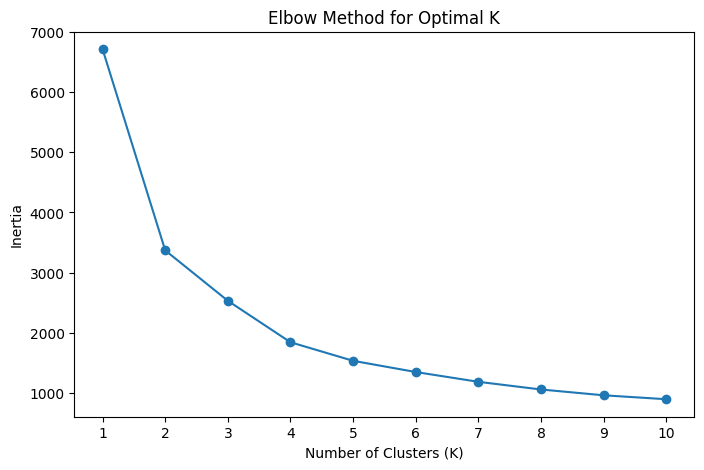


Cluster Characteristics:
         annual_spending  purchase_frequency    age
cluster                                            
0                  66.19                6.56  36.42
1                 615.42               19.72  37.03
2                 565.59               19.29  57.20
3                  89.73                7.83  55.68

Customers in Each Cluster:
cluster
0    788
1    496
2    493
3    460
Name: count, dtype: int64

Cluster 0 Strategy:
Low-engagement customers: Use discounts and personalized campaigns to encourage purchases.

Cluster 1 Strategy:
High-value frequent customers: Offer loyalty rewards and exclusive promotions.

Cluster 2 Strategy:
High-value frequent customers: Offer loyalty rewards and exclusive promotions.

Cluster 3 Strategy:
Low-engagement customers: Use discounts and personalized campaigns to encourage purchases.

Customer segments saved to 'customer_segments.csv'


In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


# Load the customer segmentation dataset
df = pd.read_csv(
    'customer_segmentation_data.csv'
)


# Select numerical features
features = [
    'annual_spending',
    'purchase_frequency',
    'age'
]

X = df[features]


# Scale the numerical features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# Calculate inertia for different numbers of clusters
inertia = []

K = range(1, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)


# Create the elbow plot
plt.figure(figsize=(8, 5))

plt.plot(
    K,
    inertia,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(list(K))

plt.savefig('elbow_plot.png')

plt.show()


# Apply K-Means clustering
optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

df['cluster'] = kmeans.fit_predict(
    X_scaled
)


# Calculate the average characteristics of each cluster
cluster_summary = (
    df.groupby('cluster')[features]
    .mean()
    .round(2)
)

print("\nCluster Characteristics:")
print(cluster_summary)


# Display the number of customers in each cluster
print("\nCustomers in Each Cluster:")

print(
    df['cluster']
    .value_counts()
    .sort_index()
)


# Calculate overall averages
average_spending = df['annual_spending'].mean()

average_frequency = df['purchase_frequency'].mean()


# Suggest a marketing strategy for each cluster
for cluster in range(optimal_k):

    spending = cluster_summary.loc[
        cluster,
        'annual_spending'
    ]

    frequency = cluster_summary.loc[
        cluster,
        'purchase_frequency'
    ]

    age = cluster_summary.loc[
        cluster,
        'age'
    ]

    print(f"\nCluster {cluster} Strategy:")

    if (
        spending > average_spending
        and frequency > average_frequency
    ):
        print(
            "High-value frequent customers: "
            "Offer loyalty rewards and exclusive promotions."
        )

    elif (
        spending > average_spending
        and frequency <= average_frequency
    ):
        print(
            "High-spending customers: "
            "Encourage more frequent purchases with special offers."
        )

    elif (
        spending <= average_spending
        and frequency > average_frequency
    ):
        print(
            "Frequent lower-spending customers: "
            "Use bundles or product upgrades to increase spending."
        )

    else:
        print(
            "Low-engagement customers: "
            "Use discounts and personalized campaigns "
            "to encourage purchases."
        )


# Save customer cluster assignments
df.to_csv(
    'customer_segments.csv',
    index=False
)


# Save the cluster summary
cluster_summary.to_csv(
    'cluster_summary.csv'
)

print(
    "\nCustomer segments saved to "
    "'customer_segments.csv'"
)

I used the Customer Personality Analysis dataset, which contains over 2,000 customer records. The purpose of this model was to divide customers into groups based on similarities in their spending, purchase frequency, and age. This can help a business better understand different types of customers and create marketing strategies for each group.

I used three numerical features: annual spending, purchase frequency, and age. Annual spending was calculated using the customer's spending across the different product categories, while purchase frequency was calculated using the customer's web, catalog, and store purchases.

Before clustering the customers, I used StandardScaler to scale the numerical features. This was important because spending, purchase frequency, and age have different ranges. Scaling helps make sure that one feature does not have more influence on the clustering simply because its numbers are larger.

I used the elbow method to determine a good number of clusters. The elbow plot shows a large decrease in inertia at first, but the improvement begins to slow around K = 4. Because the curve starts to flatten after this point, I selected 4 clusters for the K-Means model.
After applying K-Means clustering, the customers were divided into four groups with different characteristics.

Cluster 0 contained 788 customers with an average age of about 36 years, average annual spending of $66.19, and an average purchase frequency of 6.56 purchases. This group represents younger customers with relatively low spending and low purchase activity. A business could target this group with discounts, introductory offers, or personalized promotions to encourage them to purchase more often.

Cluster 1 contained 496 customers with an average age of about 37 years, average annual spending of $615.42, and an average purchase frequency of 19.72 purchases. These are younger, high-value customers who spend more money and purchase frequently. A good strategy would be to offer them loyalty rewards, exclusive promotions, or early access to new products to encourage them to continue buying.

Cluster 2 contained 493 customers with an average age of about 57 years, average annual spending of $565.59, and an average purchase frequency of 19.29 purchases. These customers are also high-value and frequent buyers, but they are older on average than Cluster 1. The business could offer this group loyalty benefits, premium product offers, and personalized recommendations based on their previous purchases.

Cluster 3 contained 460 customers with an average age of about 56 years, average annual spending of $89.73, and an average purchase frequency of 7.83 purchases. This group has lower spending and purchase activity. A business could use re-engagement offers, discounts, or special promotions to encourage these customers to purchase more frequently.